# 1. Data metering and the runtime-BAL anchor

This notebook reproduces the data-metering bridge and EIP-8279 runtime-BAL
anchor in `markdowns/bundle_priced_bal_demand_model_report.md`.

It has two execution modes. Cached mode reuses local query artifacts. Full
refresh mode queries Xatu, reconstructs the deterministic 50-block-per-day
runtime sample, and pulls complete block bodies from an Ethereum RPC endpoint.
The resulting compact handoff is consumed by notebooks 02 and 03.


In [1]:
from pathlib import Path
import os
import subprocess
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise RuntimeError("Could not locate the repository root")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

DATA_DIR = PROJECT_ROOT / "data"
OUT_DIR = DATA_DIR / "7999"
PLOT_DIR = PROJECT_ROOT / "plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

START_DATE = "2026-02-01"
END_DATE = "2026-06-01"
DATE_TAG = f"{START_DATE}_{END_DATE}"
NETWORK = "mainnet"
REFRESH_FROM_NETWORK = os.environ.get("REFRESH_7999_FROM_NETWORK", "0") == "1"
STRICT_PUBLICATION_SAMPLE = True

DAILY_XATU_CSV = OUT_DIR / f"xatu_daily_data_metering_{DATE_TAG}.csv"
RUNTIME_BLOCK_CSV = DATA_DIR / f"calibration_xatu_bal_runtime_8279_blocks_{DATE_TAG}.csv"
RUNTIME_PARTIAL_CSV = OUT_DIR / f"xatu_runtime_blocks_{DATE_TAG}.partial.csv"
RPC_STATIC_BLOCK_CSV = DATA_DIR / f"calibration_rpc_static_data_blocks_{DATE_TAG}.csv"
BRIDGE_CSV = OUT_DIR / "data_metering_bridge.csv"
ANCHOR_CSV = OUT_DIR / "data_metering_runtime_bal_anchor.csv"
DAILY_COMPONENT_CSV = OUT_DIR / "daily_data_resource_components.csv"
MANIFEST_CSV = OUT_DIR / "source_manifest.csv"
DATA_COMPONENT_PLOT = PLOT_DIR / f"daily_data_resource_components_runtime_8279_{DATE_TAG}.png"

# These three blocks were unavailable in the RPC calibration used for the
# published report. Retaining the omission reproduces the published 5,997-block
# static-field sample exactly. Set STRICT_PUBLICATION_SAMPLE=False to include a
# later successful re-fetch of those blocks.
PUBLICATION_RPC_EXCLUSIONS = {24504980, 24579284, 25205581}

pd.options.display.float_format = "{:,.6f}".format
plt.rcParams.update({
    "font.size": 14, "axes.titlesize": 16, "axes.labelsize": 14,
    "xtick.labelsize": 13, "ytick.labelsize": 13, "legend.fontsize": 13,
})

print("mode:", "full Xatu/RPC refresh" if REFRESH_FROM_NETWORK else "cached inputs")


mode: cached inputs


## Full refresh from Xatu and RPC

Set the environment variable `REFRESH_7999_FROM_NETWORK=1` before execution.
A local `.env` must provide `CLICKHOUSE_USER` and `CLICKHOUSE_PASSWORD`, plus
either `ETHNODEOPS_API_KEY` or `ALCHEMY_RPC`. Optional overrides are
`CLICKHOUSE_RAW_HOST`, `CLICKHOUSE_PORT`, and `ETHNODEOPS_RPC`.

Xatu supplies canonical block coverage, transaction content, and the protocol
events used by the EIP-8279 runtime counter. RPC supplies complete transaction
bodies for access lists and authorization tuples. The RPC path is resumable;
completed 50-block chunks are retained under `data/`.


In [2]:
import clickhouse_connect
from dotenv import load_dotenv

from sim.rpc_calibration import sample_blocks_per_day
from sim.xatu_bal_8279 import query_xatu_eip8279_runtime_blocks


def xatu_client():
    load_dotenv(PROJECT_ROOT / ".env")
    required = ["CLICKHOUSE_USER", "CLICKHOUSE_PASSWORD"]
    missing = [name for name in required if not os.environ.get(name)]
    if missing:
        raise RuntimeError(
            "Full refresh requires these .env values: " + ", ".join(missing)
        )
    return clickhouse_connect.get_client(
        host=os.environ.get(
            "CLICKHOUSE_RAW_HOST", "clickhouse-raw.xatu.ethpandaops.io"
        ),
        port=int(os.environ.get("CLICKHOUSE_PORT", "443")),
        username=os.environ["CLICKHOUSE_USER"],
        password=os.environ["CLICKHOUSE_PASSWORD"],
        secure=True,
    )


def query_daily_data_metering(client):
    return client.query_df(
        """
        WITH
            blocks AS
            (
                SELECT block_number, toDate(block_date_time) AS date
                FROM default.canonical_execution_block FINAL
                WHERE meta_network_name = {network:String}
                  AND block_date_time >= parseDateTime64BestEffort({start_ts:String})
                  AND block_date_time < parseDateTime64BestEffort({end_ts:String})
            ),
            receipts AS
            (
                SELECT
                    block_number,
                    sum(
                        if(
                            greatest(toInt64(gas_used) - 21000, 0)
                                <= toInt64(10 * (n_input_zero_bytes + 4 * n_input_nonzero_bytes))
                            AND (n_input_zero_bytes + n_input_nonzero_bytes) > 0,
                            toInt64(10 * (n_input_zero_bytes + 4 * n_input_nonzero_bytes)),
                            toInt64(4 * (n_input_zero_bytes + 4 * n_input_nonzero_bytes))
                        )
                    ) AS data_gas_current
                FROM default.canonical_execution_transaction FINAL
                WHERE meta_network_name = {network:String}
                  AND block_number IN (SELECT block_number FROM blocks)
                GROUP BY block_number
            ),
            content AS
            (
                SELECT
                    block_number,
                    sum(toUInt64(n_input_bytes)) AS calldata_bytes,
                    sum(toUInt64(4 * n_input_zero_bytes + 16 * n_input_nonzero_bytes))
                        AS standard_calldata_gas,
                    sum(length(blob_hashes)) AS blob_versioned_hash_count
                FROM default.execution_transaction FINAL
                WHERE meta_network_name = {network:String}
                  AND block_number IN (SELECT block_number FROM blocks)
                GROUP BY block_number
            )
        SELECT
            b.date,
            count() AS block_count,
            min(b.block_number) AS min_block,
            max(b.block_number) AS max_block,
            sum(ifNull(r.data_gas_current, 0)) AS data_gas_current,
            sum(ifNull(c.standard_calldata_gas, 0)) AS standard_calldata_gas,
            sum(ifNull(c.calldata_bytes, 0)) AS calldata_bytes,
            sum(ifNull(c.blob_versioned_hash_count, 0)) AS blob_versioned_hash_count
        FROM blocks AS b
        GLOBAL LEFT JOIN receipts AS r USING block_number
        GLOBAL LEFT JOIN content AS c USING block_number
        GROUP BY b.date
        ORDER BY b.date
        """,
        parameters={
            "network": NETWORK,
            "start_ts": f"{START_DATE} 00:00:00",
            "end_ts": f"{END_DATE} 00:00:00",
        },
        settings={"max_execution_time": 1200},
    )


def refresh_runtime_blocks(client, targets, chunk_size=200):
    completed = pd.DataFrame()
    for candidate in (RUNTIME_PARTIAL_CSV, RUNTIME_BLOCK_CSV):
        if candidate.exists():
            completed = pd.read_csv(candidate)
            break
    completed_numbers = set(
        completed.get("block_number", pd.Series(dtype="int64")).astype(int)
    )
    missing = [
        int(block) for block in targets["block_number"]
        if int(block) not in completed_numbers
    ]
    print(f"runtime cache: {len(completed_numbers):,} blocks; querying {len(missing):,}")
    pieces = [completed]
    for start in range(0, len(missing), chunk_size):
        block_numbers = missing[start:start + chunk_size]
        piece = query_xatu_eip8279_runtime_blocks(
            client, block_numbers, network=NETWORK
        )
        pieces.append(piece)
        checkpoint = (
            pd.concat(pieces, ignore_index=True)
            .drop_duplicates("block_number", keep="last")
            .sort_values("block_number")
        )
        checkpoint.to_csv(RUNTIME_PARTIAL_CSV, index=False)
        print(f"runtime queried: {min(start + len(block_numbers), len(missing)):,}/{len(missing):,}")

    combined = pd.concat(pieces, ignore_index=True).drop_duplicates(
        "block_number", keep="last"
    )
    output = targets.merge(
        combined.drop(columns=["date", "sample_rank"], errors="ignore"),
        on="block_number", how="left", validate="one_to_one",
    )
    if output.isna().any().any():
        raise ValueError("The runtime refresh did not return every sampled block")
    output.to_csv(RUNTIME_BLOCK_CSV, index=False)
    if RUNTIME_PARTIAL_CSV.exists():
        RUNTIME_PARTIAL_CSV.unlink()
    return output


if REFRESH_FROM_NETWORK:
    client = xatu_client()
    daily_source = query_daily_data_metering(client)
    daily_source["date"] = pd.to_datetime(daily_source["date"])
    daily_source["blob_versioned_hash_bytes"] = (
        32 * daily_source["blob_versioned_hash_count"]
    )
    daily_source.to_csv(DAILY_XATU_CSV, index=False)

    plan = sample_blocks_per_day(
        daily_source[["date", "min_block", "max_block"]],
        n_per_day=500,
        seed=42,
    )
    targets = plan[plan["sample_rank"] < 50][
        ["date", "block_number", "sample_rank"]
    ].reset_index(drop=True)
    runtime_refreshed = refresh_runtime_blocks(client, targets)

    subprocess.run(
        [
            sys.executable,
            str(PROJECT_ROOT / "scripts" / "build_rpc_static_data_panel.py"),
            "--block-input", str(RUNTIME_BLOCK_CSV),
            "--chunk-size", "50",
            "--max-workers", "8",
        ],
        cwd=PROJECT_ROOT,
        check=True,
    )
else:
    if not DAILY_XATU_CSV.exists():
        legacy_accounting = DATA_DIR / f"daily_accounting_panel_calibrated_with_bal_{DATE_TAG}.csv"
        legacy_current = DATA_DIR / f"daily_current_data_gas_xatu_{DATE_TAG}.csv"
        if not legacy_accounting.exists() or not legacy_current.exists():
            raise FileNotFoundError(
                "Cached daily inputs are absent. Set REFRESH_7999_FROM_NETWORK=1 "
                "and provide the .env credentials documented above."
            )
        accounting = pd.read_csv(legacy_accounting)
        current = pd.read_csv(legacy_current)[["date", "data_gas_current"]]
        daily_source = accounting[[
            "date", "block_count", "min_block", "max_block",
            "standard_calldata_gas", "calldata_bytes",
            "blob_versioned_hash_count", "blob_versioned_hash_bytes",
        ]].merge(current, on="date", how="left", validate="one_to_one")
        daily_source.to_csv(DAILY_XATU_CSV, index=False)
        print("constructed", DAILY_XATU_CSV.relative_to(PROJECT_ROOT), "from legacy caches")
    else:
        daily_source = pd.read_csv(DAILY_XATU_CSV)


constructed data/7999/xatu_daily_data_metering_2026-02-01_2026-06-01.csv from legacy caches


## Static-data metering bridge

The bridge starts from current EIP-7623 data gas, removes the floor uplift,
applies flat 16-gas-per-byte calldata metering, and adds access lists,
authorization tuples, their 51-byte static BAL entries, and blob hashes.
Runtime BAL is shown as a final reconciliation step but remains behaviorally
separate from static data in the demand model.


In [3]:
required = [DAILY_XATU_CSV, RUNTIME_BLOCK_CSV, RPC_STATIC_BLOCK_CSV]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing source caches. Use REFRESH_7999_FROM_NETWORK=1 to rebuild:\n- "
        + "\n- ".join(missing)
    )

daily = pd.read_csv(DAILY_XATU_CSV)
runtime_blocks = pd.read_csv(RUNTIME_BLOCK_CSV)
rpc_static = pd.read_csv(RPC_STATIC_BLOCK_CSV)
daily["date"] = pd.to_datetime(daily["date"])
runtime_blocks["date"] = pd.to_datetime(runtime_blocks["date"])

assert len(daily) == 120
assert runtime_blocks["block_number"].nunique() == 6_000
assert runtime_blocks.groupby("date")["block_number"].size().eq(50).all()

rpc_sample = runtime_blocks[["date", "block_number"]].merge(
    rpc_static, on="block_number", how="inner", validate="one_to_one"
)
if STRICT_PUBLICATION_SAMPLE:
    rpc_sample = rpc_sample[
        ~rpc_sample["block_number"].isin(PUBLICATION_RPC_EXCLUSIONS)
    ].copy()
    assert len(rpc_sample) == 5_997
else:
    assert len(rpc_sample) == 6_000

sample_daily = rpc_sample.groupby("date", as_index=False).agg(
    rpc_sampled_blocks=("block_number", "size"),
    access_list_bytes_per_block=("tx_access_list_bytes", "mean"),
    authorization_tuple_bytes_per_block=("authorization_tuple_8131_bytes", "mean"),
    authorization_tuple_count_per_block=("authorization_tuple_count", "mean"),
)
runtime_daily = runtime_blocks.groupby("date", as_index=False).agg(
    runtime_sampled_blocks=("block_number", "size"),
    runtime_bal_bytes_per_block=("bal_runtime_bytes_8279", "mean"),
)
panel = (
    daily.merge(sample_daily, on="date", how="left", validate="one_to_one")
    .merge(runtime_daily, on="date", how="left", validate="one_to_one")
)
if panel.isna().any().any():
    raise ValueError("A daily source or sampled field is missing")

blocks = float(panel["block_count"].sum())
current_data = float(panel["data_gas_current"].sum())
base_4_16 = float(panel["standard_calldata_gas"].sum())
flat16_calldata = float(16 * panel["calldata_bytes"].sum())
access_lists = float(
    16 * (panel["access_list_bytes_per_block"] * panel["block_count"]).sum()
)
authorization_tuples = float(
    16 * (panel["authorization_tuple_bytes_per_block"] * panel["block_count"]).sum()
)
authorization_static_bal = float(
    16 * 51
    * (panel["authorization_tuple_count_per_block"] * panel["block_count"]).sum()
)
blob_hashes = float(16 * panel["blob_versioned_hash_bytes"].sum())
runtime_bal = float(
    16 * (panel["runtime_bal_bytes_per_block"] * panel["block_count"]).sum()
)
static_data = (
    flat16_calldata + access_lists + authorization_tuples
    + authorization_static_bal + blob_hashes
)
with_runtime_bal = static_data + runtime_bal

bridge_rows = [
    ("current_eip7623", "current 4/16 calldata plus EIP-7623 floor uplift", current_data),
    ("base_eip7999_tx_data", "remove EIP-7623 floor; retain 4/16 calldata", base_4_16),
    ("flat16_calldata", "meter every calldata byte at 16 data gas", flat16_calldata),
    ("plus_access_lists", "add sampled access-list bytes", flat16_calldata + access_lists),
    ("plus_authorization_tuples", "add sampled 108-byte authorization tuples", flat16_calldata + access_lists + authorization_tuples),
    ("plus_authorization_static_bal", "add 51 static BAL bytes per authorization", flat16_calldata + access_lists + authorization_tuples + authorization_static_bal),
    ("plus_blob_hashes", "add exact 32-byte blob-versioned hashes", static_data),
    ("plus_runtime_bal", "add EIP-8279 runtime BAL at 16 data gas per byte", with_runtime_bal),
]
bridge = pd.DataFrame(bridge_rows, columns=["scenario", "definition", "total_data_gas"])
bridge["data_gas_per_block"] = bridge["total_data_gas"] / blocks
bridge["incremental_gas_per_block"] = bridge["total_data_gas"].diff() / blocks
bridge["multiplier_vs_current_eip7623"] = bridge["total_data_gas"] / current_data
bridge.to_csv(BRIDGE_CSV, index=False)
display(bridge[["scenario", "data_gas_per_block", "incremental_gas_per_block", "multiplier_vs_current_eip7623"]])


,scenario,data_gas_per_block,incremental_gas_per_block,multiplier_vs_current_eip7623
0,current_eip7623,"1,180,555.063055",NaN,1.000000
1,base_eip7999_tx_data,"1,032,928.461845","-147,626.601210",0.874952
2,flat16_calldata,"2,008,812.803979","975,884.342134",1.701583
3,plus_access_lists,"2,100,736.666215","91,923.862236",1.779448
4,plus_authorization_tuples,"2,121,778.277184","21,041.610969",1.797272
5,plus_authorization_static_bal,"2,131,714.593475","9,936.316291",1.805688
6,plus_blob_hashes,"2,133,558.806164","1,844.212689",1.807251
7,plus_runtime_bal,"4,052,658.698145","1,919,099.891982",3.432842


## Runtime-BAL anchor and report reconciliation

The runtime anchor is a canonical-block-count-weighted average of the 50
deterministic sampled blocks per day. The EIP-7999 counterfactual prices each
runtime byte at 16 data gas.


In [4]:
anchor = pd.DataFrame([{
    "start_date": START_DATE,
    "end_date_inclusive": "2026-05-31",
    "days": len(panel),
    "canonical_blocks": blocks,
    "runtime_sample_blocks": len(runtime_blocks),
    "static_rpc_sample_blocks": len(rpc_sample),
    "publication_rpc_exclusions": ",".join(map(str, sorted(PUBLICATION_RPC_EXCLUSIONS)))
        if STRICT_PUBLICATION_SAMPLE else "",
    "current_eip7623_data_gas_per_block": current_data / blocks,
    "base_eip7999_4_16_data_gas_per_block": base_4_16 / blocks,
    "flat16_calldata_gas_per_block": flat16_calldata / blocks,
    "access_list_data_gas_per_block": access_lists / blocks,
    "authorization_tuple_data_gas_per_block": authorization_tuples / blocks,
    "authorization_static_bal_data_gas_per_block": authorization_static_bal / blocks,
    "blob_hash_data_gas_per_block": blob_hashes / blocks,
    "static_data_gas_per_block": static_data / blocks,
    "runtime_bal_bytes_per_block": runtime_bal / 16 / blocks,
    "runtime_bal_data_gas_per_block": runtime_bal / blocks,
    "data_gas_with_runtime_bal_per_block": with_runtime_bal / blocks,
    "static_data_metering_multiplier": static_data / current_data,
    "data_metering_multiplier_with_runtime_bal": with_runtime_bal / current_data,
    "runtime_bal_share_of_total_data_gas": runtime_bal / with_runtime_bal,
}])
anchor.to_csv(ANCHOR_CSV, index=False)

expected = {
    "static_data_gas_per_block": 2_133_558.806164,
    "runtime_bal_bytes_per_block": 119_943.743249,
    "runtime_bal_data_gas_per_block": 1_919_099.891982,
    "static_data_metering_multiplier": 1.807251,
    "data_metering_multiplier_with_runtime_bal": 3.432842,
}
for field, value in expected.items():
    if not np.isclose(float(anchor.loc[0, field]), value, rtol=2e-7, atol=1e-6):
        raise AssertionError(f"publication anchor changed for {field}")

display(anchor.T)
print("wrote", ANCHOR_CSV.relative_to(PROJECT_ROOT))


,0
start_date,2026-02-01
end_date_inclusive,2026-05-31
days,120
canonical_blocks,"860,505.000000"
runtime_sample_blocks,6000
static_rpc_sample_blocks,5997
publication_rpc_exclusions,"24504980,24579284,25205581"
current_eip7623_data_gas_per_block,"1,180,555.063055"
base_eip7999_4_16_data_gas_per_block,"1,032,928.461845"
flat16_calldata_gas_per_block,"2,008,812.803979"


wrote data/7999/data_metering_runtime_bal_anchor.csv


## Daily data-resource composition


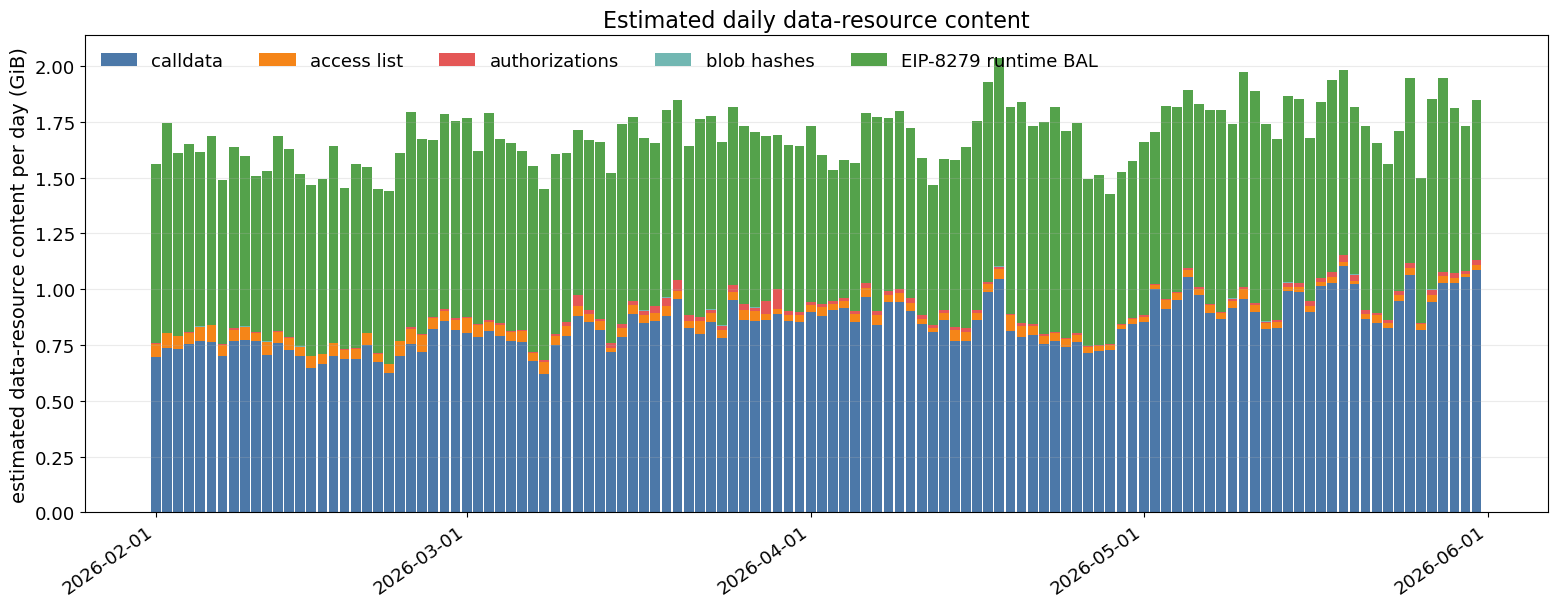

,artifact,path,role
0,xatu_daily_data_metering_2026-02-01_2026-06-01...,data/7999/xatu_daily_data_metering_2026-02-01_...,full-panel Xatu daily data accounting
1,calibration_xatu_bal_runtime_8279_blocks_2026-...,data/calibration_xatu_bal_runtime_8279_blocks_...,"deterministic 6,000-block EIP-8279 runtime sample"
2,calibration_rpc_static_data_blocks_2026-02-01_...,data/calibration_rpc_static_data_blocks_2026-0...,full transaction-body static fields for sample...
3,data_metering_runtime_bal_anchor.csv,data/7999/data_metering_runtime_bal_anchor.csv,handoff to BAL decomposition and equilibrium


In [5]:
daily_components = panel[["date", "block_count", "calldata_bytes", "blob_versioned_hash_bytes"]].copy()
daily_components["access_list_bytes"] = (
    panel["access_list_bytes_per_block"] * panel["block_count"]
)
daily_components["authorization_bytes"] = (
    (panel["authorization_tuple_bytes_per_block"]
     + 51 * panel["authorization_tuple_count_per_block"])
    * panel["block_count"]
)
daily_components["runtime_bal_bytes"] = (
    panel["runtime_bal_bytes_per_block"] * panel["block_count"]
)
daily_components.to_csv(DAILY_COMPONENT_CSV, index=False)

component_columns = [
    "calldata_bytes", "access_list_bytes", "authorization_bytes",
    "blob_versioned_hash_bytes", "runtime_bal_bytes",
]
labels = ["calldata", "access list", "authorizations", "blob hashes", "EIP-8279 runtime BAL"]
colors = ["#4c78a8", "#f58518", "#e45756", "#72b7b2", "#54a24b"]
fig, ax = plt.subplots(figsize=(15.8, 6.3))
bottom = np.zeros(len(daily_components))
for column, label, color in zip(component_columns, labels, colors):
    values = daily_components[column].to_numpy(dtype=float) / 2**30
    ax.bar(daily_components["date"], values, bottom=bottom, width=0.88, color=color, label=label)
    bottom += values
ax.set_ylabel("estimated data-resource content per day (GiB)")
ax.set_title("Estimated daily data-resource content")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
ax.legend(frameon=False, ncol=5, loc="upper left")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(DATA_COMPONENT_PLOT, dpi=220, bbox_inches="tight")
plt.show()

manifest = pd.DataFrame([
    {"artifact": path.name, "path": str(path.relative_to(PROJECT_ROOT)), "role": role}
    for path, role in [
        (DAILY_XATU_CSV, "full-panel Xatu daily data accounting"),
        (RUNTIME_BLOCK_CSV, "deterministic 6,000-block EIP-8279 runtime sample"),
        (RPC_STATIC_BLOCK_CSV, "full transaction-body static fields for sampled blocks"),
        (ANCHOR_CSV, "handoff to BAL decomposition and equilibrium"),
    ]
])
manifest.to_csv(MANIFEST_CSV, index=False)
manifest
